In [ ]:
import argparse
import os, sys
import time
import datetime

# Import pytorch dependencies
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm import tqdm_notebook as tqdm

from dataloader import CIFAR10

In [ ]:
# Setting some hyperparameters
TRAIN_BATCH_SIZE = 128
VAL_BATCH_SIZE = 100
INITIAL_LR = 0.1
MOMENTUM = 0.9
REG = 5e-4 # 1e-4
EPOCHS = 150 # 30
DATAROOT = "./data"
CHECKPOINT_PATH = "./saved_model"

In [ ]:
# Specify preprocessing function.
# Reference mean/std value for
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)


transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # Augmentation: Padding + Crop
    transforms.RandomHorizontalFlip(),    # Augmentation: Flip
    transforms.ToTensor(),                # Convert to [0, 1] range
    transforms.Normalize(mean, std)       # Standardization
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [ ]:
# Call the dataset Loader
trainset = CIFAR10(root=DATAROOT, train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, num_workers=1)
valset = CIFAR10(root=DATAROOT, train=False, download=True, transform=transform_val)
valloader = torch.utils.data.DataLoader(valset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=1)

Using downloaded and verified file: ./data/cifar10_trainval.tar.gz
Extracting ./data/cifar10_trainval.tar.gz to ./data
Files already downloaded and verified
Using downloaded and verified file: ./data/cifar10_trainval.tar.gz
Extracting ./data/cifar10_trainval.tar.gz to ./data
Files already downloaded and verified


In [ ]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class CIFAR10Test(Dataset):
    """
    CIFAR-10 test dataset (no labels).

    Loads a .npy array of images shaped like (N, 32, 32, 3) and returns
    transformed PIL images ready for inference.

    :param self: Instance of the dataset class.
    :param root: Root directory where the test .npy file is stored.
    :type root: str
    :param transform: Transformations to apply to each image.
    :type transform: torchvision.transforms or callable
    :param filename: Name of the .npy file containing test images.
                     Defaults to "cifar10-batches-images-test.npy".
    :type filename: str
    """
    def __init__(self, root, transform=None, filename="cifar10-batches-images-test.npy"):
        self.root = root
        self.transform = transform
        self.filename = filename

        img_path = os.path.join(root, filename)
        self.data = np.load(img_path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img = self.data[index]              # numpy array (32,32,3)
        img = Image.fromarray(img)          # convert to PIL

        if self.transform is not None:
            img = self.transform(img)

        return img, index                   # return index to match predictions

In [ ]:
testset = CIFAR10Test(root=DATAROOT, transform=transform_val)
testloader = torch.utils.data.DataLoader(testset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=1)

In [ ]:
# Comfirming the testset loads correctly
img, idx = testset[0]
print(idx)
print(type(img), getattr(img, "shape", None))

0
<class 'torch.Tensor'> torch.Size([3, 32, 32])


In [ ]:
# Create the neural network module: DNN
class CustomDNN(nn.Module):
    def __init__(self):
        super(CustomDNN, self).__init__()
        # CIFAR-10 is 32x32 "colorful," which means 3 input channels

        # Initial Feature Extraction
        # Input: (N,3,32,32)  -> Output: (N,32,32,32)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)

        # Residual Block 1
        # Main path: 32 -> 32 -> 32, same spatial size
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(32)

        # MaxPool
        # 32x32 -> 16x16
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Residual Block 2 (16x16)
        # Main path: 32 -> 64 -> 64
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn5 = nn.BatchNorm2d(64)

        # Shortcut for Block 2 to match dimensions (32 channels -> 64 channels)
        # This allows the identity tensor to have the same shape as the main path
        # so they can be added together in the residual skip connection
        self.shortcut1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(64)
        )

        ## Residual Block 3 (8x8)
        # Main path: 64 -> 128 -> 128
        self.conv6 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn6 = nn.BatchNorm2d(128)
        self.conv7 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn7 = nn.BatchNorm2d(128)

        # Shortcut for Block 3 to match dimensions (64 -> 128 channels, 16x16 -> 8x8)
        self.shortcut2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(128)
        )

        # Output layers
        # (N,128,8,8) -> (N,128,1,1)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        # Input: (N,3,32,32)

        # Layer 1: Conv -> BN -> ReLU
        x = self.conv1(x)         # (N,3,32,32)
        x = self.bn1(x)           # (N,32,32,32)
        x = F.relu(x)             # (N,32,32,32)

        # Residual Block 1
        # Save identity for skip
        identity = x              # (N,32,32,32)
        out = self.conv2(x)       # (N,32,32,32)
        out = self.bn2(out)
        out = F.relu(out)
        out = self.conv3(out)     # (N,32,32,32)
        out = self.bn3(out)
        # Skip Connection
        out = out + identity      # (N,32,32,32)
        x = F.relu(out)           # (N,32,32,32)

        # Residual Block 2
        # Shortcut Projection
        identity = self.shortcut1(x)
        out = self.conv4(x)        # (N,64,16,16) via stride=2
        out = self.bn4(out)
        out = F.relu(out)
        out = self.conv5(out)      # (N,64,16,16)
        out = self.bn5(out)
        # Skip connection
        out = out + identity
        x = F.relu(out)            # (N,64,16,16)

        # Residual Block 3
        # Shortcut Projection
        identity = self.shortcut2(x)
        out = self.conv6(x)        # (N,128,8,8) via stride=2
        out = self.bn6(out)
        out = F.relu(out)
        out = self.conv7(out)      # (N,128,8,8)
        out = self.bn7(out)
        # Skip connection
        out = out + identity
        x = F.relu(out)            # (N,128,8,8)


        # Classifier
        # Global Average Pool
        # Reduces each feature map to a single value. It summarizes the spatial information
        # and greatly reduces the number of parameters before the final classifier
        x = self.avg_pool(x)       # (N,128,1,1)
        x = torch.flatten(x, 1)    # (N,128)
        x = self.fc(x)             # (N,10)

        return x

In [ ]:
# FLAG for loading the pretrained model
TRAIN_FROM_SCRATCH = True
# Code for loading checkpoint and recover epoch id.
CKPT_PATH = "./saved_model/model.h5"
def get_checkpoint(ckpt_path):
    try:
        ckpt = torch.load(ckpt_path)
    except Exception as e:
        print(e)
        return None
    return ckpt

ckpt = get_checkpoint(CKPT_PATH)
if ckpt is None or TRAIN_FROM_SCRATCH:
    if not TRAIN_FROM_SCRATCH:
        print("Checkpoint not found.")
    print("Training from scratch ...")
    start_epoch = 0
    current_learning_rate = INITIAL_LR
else:
    print("Successfully loaded checkpoint: %s" %CKPT_PATH)
    net.load_state_dict(ckpt['net'])
    start_epoch = ckpt['epoch'] + 1
    current_learning_rate = ckpt['lr']
    print("Starting from epoch %d " %start_epoch)

print("Starting from learning rate %f:" %current_learning_rate)

Training from scratch ...
Starting from learning rate 0.100000:


In [ ]:
# Specify the device for computation
device = 'cuda' if torch.cuda.is_available() else 'cpu'
net = CustomDNN()
net = net.to(device)
if device =='cuda':
    print("Train on GPU...")
else:
    print("Train on CPU...")

Train on GPU...


In [ ]:
# Create loss function and specify regularization
criterion = nn.CrossEntropyLoss()
# Add optimizer
optimizer = optim.SGD(
    net.parameters(),
    lr=INITIAL_LR,
    momentum=MOMENTUM,
    weight_decay=REG # L2
)

In [ ]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

In [ ]:
"""Main Training and Validation Loop"""
history = {
    "epoch": [],
    "train_acc": [],
    "val_acc": [],
}

global_step = 0
best_val_acc = 0

for i in range(start_epoch, EPOCHS):
    print(datetime.datetime.now())
    # Switch to train mode
    net.train()
    print("Epoch %d:" %i)

    total_examples = 0
    correct_examples = 0

    train_loss = 0
    train_acc = 0
    # Train the training dataset for 1 epoch.
    print(len(trainloader))
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        # Copy inputs to device
        inputs = inputs.to(device)
        targets = targets.to(device)
        # Zero the gradient
        optimizer.zero_grad()
        # Generate output
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        # Now backward loss
        loss.backward()
        # Apply gradient
        optimizer.step()
        # Calculate predicted labels
        _, predicted = outputs.max(1)
        # Calculate accuracy
        total_examples += targets.size(0)
        correct_examples += predicted.eq(targets).sum().item()

        train_loss += loss.item()

        global_step += 1
        if global_step % 100 == 0:
            avg_loss = train_loss / (batch_idx + 1)
        pass
    avg_acc = correct_examples / total_examples
    print("Training loss: %.4f, Training accuracy: %.4f" %(avg_loss, avg_acc))
    print(datetime.datetime.now())
    # Validate on the validation dataset
    print("Validation...")
    total_examples = 0
    correct_examples = 0

    net.eval()

    val_loss = 0
    val_acc = 0
    # Disable gradient during validation
    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(valloader):
            # Copy inputs to device
            inputs = inputs.to(device)
            targets = targets.to(device)
            # Zero the gradient
            optimizer.zero_grad()
            # Generate output from the DNN.
            outputs = net(inputs)
            loss = criterion(outputs, targets)
            # Calculate predicted labels
            _, predicted = outputs.max(1)
            # Calculate accuracy
            total_examples += targets.size(0)
            correct_examples += predicted.eq(targets).sum().item()
            val_loss += loss.item()

    avg_loss_val = val_loss / len(valloader)
    avg_acc_val = correct_examples / total_examples
    print("Validation loss: %.4f, Validation accuracy: %.4f" % (avg_loss_val, avg_acc_val))


    history["epoch"].append(i)
    history["train_acc"].append(avg_acc)
    history["val_acc"].append(avg_acc_val)

    # This replaces the manual DECAY_EPOCHS and DECAY logic
    scheduler.step()
    current_learning_rate = scheduler.get_last_lr()[0]
    print("Current learning rate is %f" % current_learning_rate)

    # Save for checkpoint
    if avg_acc_val > best_val_acc:
        best_val_acc = avg_acc_val
        if not os.path.exists(CHECKPOINT_PATH):
            os.makedirs(CHECKPOINT_PATH)
        print("Saving ...")
        state = {'net': net.state_dict(),
                 'epoch': i,
                 'lr': current_learning_rate}
        torch.save(state, os.path.join(CHECKPOINT_PATH, 'model.h5'))

print("Optimization finished.")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import copy

"""Visualization and Analysis"""

def plot_learning_curve(history, title="Training vs Validation Accuracy"):
    """
    Plot training and validation accuracy over training epochs.

    :param history: Dictionary containing training history with keys "epoch", "train_acc", and "val_acc".
    :type history: dict
    :param title: Title of the plot.
    :type title: str
    """
    plt.figure()
    plt.plot(history["epoch"], history["train_acc"], label="Training Accuracy")
    plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

import pandas as pd

def history_to_dataframe(history):
    """
    Convert the history dictionary into a pandas DataFrame.

    :param history: Dictionary containing training history with keys "epoch", "train_acc", and "val_acc".
    :type history: dict
    :return: DataFrame with columns for epoch, training accuracy, and validation accuracy.
    :rtype: pandas.DataFrame
    """
    df = pd.DataFrame({
        "epoch": history["epoch"],
        "train_acc": history["train_acc"],
        "val_acc": history["val_acc"]
    })
    return df


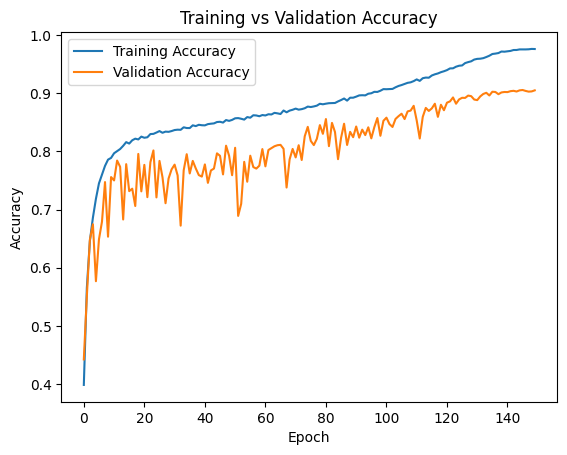

,epoch,train_acc,val_acc
0,0,0.398356,0.4422
1,1,0.565578,0.5512
2,2,0.645956,0.6482
3,3,0.686156,0.6748
4,4,0.718622,0.5768
...,...,...,...
145,145,0.975644,0.9058
146,146,0.975644,0.9042
147,147,0.975867,0.9030
148,148,0.976489,0.9034


In [ ]:
# Define hyperparameters
# TRAIN_BATCH_SIZE = 128
# VAL_BATCH_SIZE = 100
# INITIAL_LR = 0.01
# MOMENTUM = 0.9
# REG = 1e-4
# EPOCHS = 30
# No Augmentation
# No Batch Normalization

baseline = copy.deepcopy(history)
plot_learning_curve(baseline)

baseline_df = history_to_dataframe(baseline)
display(baseline_df)

In [ ]:
import pandas as pd

"""Prediction on Test Set"""
# Load the best weights from trained model
checkpoint = torch.load(os.path.join(CHECKPOINT_PATH, 'model.h5'))
net.load_state_dict(checkpoint['net'])
net.to(device)
net.eval()

all_preds = []
all_ids = []

with torch.no_grad():
    for images, idxs in tqdm(testloader):
        images = images.to(device)
        outputs = net(images)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_ids.extend(idxs.numpy())

# Create DataFrame
submission = pd.DataFrame({
    'Id': all_ids,
    'Category': all_preds
})

# Sort by Id
submission = submission.sort_values('Id')
submission.to_csv('final_submission.csv', index=False)
print("Done! 'final_submission.csv' is ready.")

In [ ]:
"""
Calculate the total number of parameters in the CustomDNN architecture.
"""
# Initial Conv Layer
# Conv1: (3 -> 32), 3x3 kernel, no bias
conv1 = (3 * 3 * 3 * 32)
# BatchNorm1: gamma + beta
bn1 = (32 * 2)

layer1 = conv1 + bn1

# Residual Block 1
# Conv2: (32 -> 32), 3x3
conv2 = (3 * 3 * 32 * 32)
bn2 = (32 * 2)

# Conv3: (32 -> 32), 3x3
conv3 = (3 * 3 * 32 * 32)
bn3 = (32 * 2)

block1 = conv2 + bn2 + conv3 + bn3

# Residual Block 2
# Conv4: (32 -> 64), 3x3
conv4 = (3 * 3 * 32 * 64)
bn4 = (64 * 2)
# Conv5: (64 -> 64), 3x3
conv5 = (3 * 3 * 64 * 64)
bn5 = (64 * 2)
# Shortcut1: 1x1 conv (32 -> 64)
shortcut1_conv = (1 * 1 * 32 * 64)
shortcut1_bn = (64 * 2)

block2 = conv4 + bn4 + conv5 + bn5 + shortcut1_conv + shortcut1_bn


# Residual Block 3
# Conv6: (64 -> 128), 3x3
conv6 = (3 * 3 * 64 * 128)
bn6 = (128 * 2)
# Conv7: (128 -> 128), 3x3
conv7 = (3 * 3 * 128 * 128)
bn7 = (128 * 2)
# Shortcut2: 1x1 conv (64 -> 128)
shortcut2_conv = (1 * 1 * 64 * 128)
shortcut2_bn = (128 * 2)

block3 = conv6 + bn6 + conv7 + bn7 + shortcut2_conv + shortcut2_bn

# Fully Connected Layer
# FC: (128 -> 10) with bias
fc = (128 * 10) + 10

# Total Parameters
total_params = layer1 + block1 + block2 + block3 + fc

print(f"Total number of parameters: {total_params}")

Total number of parameters: 308650
